# Rice Guard: executed GloRice visualization rerun

The selected visualization cells below are copied unchanged from the supplied notebook. They use the newly reconstructed annual model outputs, not the unavailable original training implementation. APRA500 legacy and unrelated FAO ADM1 sections are excluded. The original notebook is unchanged.

In [1]:
from pathlib import Path
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
ROOT=Path('D:\\Perlombaan Duniawi\\Rasio Infog\\riceguard_web')
PROCESSED=ROOT/'data/processed'
MODEL_DIR=PROCESSED/'glorice/model'
# The helper reproduces the boundary overlay using the downloaded GADM GeoJSON.
def draw_asean_boundaries(ax):
    ax.set_facecolor('#edf2f4')
    for code in ['BRN', 'KHM', 'IDN', 'LAO', 'MYS', 'MMR', 'PHL', 'SGP', 'THA', 'VNM']:
        with zipfile.ZipFile(ROOT/f'data/raw/gadm41_adm0/gadm41_{code}_0.json.zip') as archive:
            name=next(n for n in archive.namelist() if n.endswith('.json'))
            geometry=json.loads(archive.read(name))['features'][0]['geometry']
        polygons=geometry['coordinates'] if geometry['type']=='MultiPolygon' else [geometry['coordinates']]
        for polygon in polygons:
            for ring in polygon:
                xy=np.asarray(ring);ax.plot(xy[:,0],xy[:,1],color='#2b2b2b',linewidth=.55,zorder=3)
    return ax


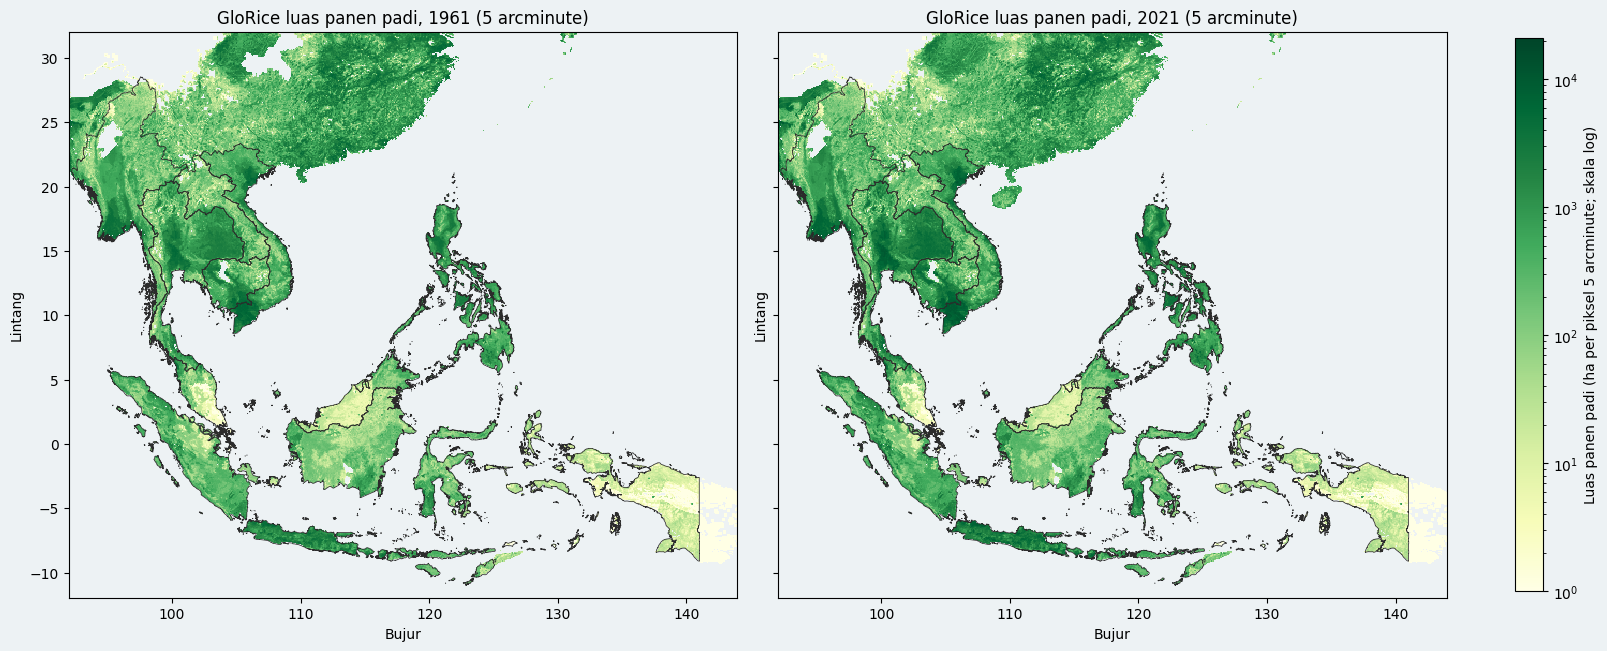

GloRice menggantikan APRA500 untuk visualisasi dan model Indonesia/ASEAN.


In [2]:
glorice = np.load(PROCESSED / 'glorice/glorice_sea_intensive_harvested_area_1961_2021.npz')
glorice_years, glorice_area = glorice['years'], glorice['area_ha']
glorice_lon, glorice_lat = glorice['lon'], glorice['lat']
assert glorice_area.shape[0] == len(glorice_years) == 61
from matplotlib.colors import LogNorm
import rasterio
pixel_5arc = abs(glorice_lon[1] - glorice_lon[0])
# Batas luar piksel, bukan hanya titik pusat: identik dengan extent GeoTIFF visual 2030 5 arcminute.
extent_glorice = [glorice_lon.min()-pixel_5arc/2, glorice_lon.max()+pixel_5arc/2, glorice_lat.min()-pixel_5arc/2, glorice_lat.max()+pixel_5arc/2]
area_1961 = glorice_area[np.where(glorice_years == 1961)[0][0]]
area_2021 = glorice_area[np.where(glorice_years == 2021)[0][0]]
# Skala bersama 5 arcminute: juga mencakup maksimum visual 2030 yang telah didisagregasi.
vmax_5arc = np.nanmax(np.stack([area_1961, area_2021]))
for scenario in ('ssp245', 'ssp585'):
    with rasterio.open(PROCESSED / 'glorice/model' / f'glorice_pattern_disaggregated_{scenario}_2030_5arcmin.tif') as src:
        vmax_5arc = max(vmax_5arc, float(src.read(1, masked=True).max()))
norm_5arc = LogNorm(vmin=1, vmax=vmax_5arc)
cmap_5arc = plt.get_cmap('YlGn').copy()
cmap_5arc.set_bad('#edf2f4')
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True, constrained_layout=True, facecolor='#edf2f4')
for ax, year, area in zip(axes, (1961, 2021), (area_1961, area_2021)):
    image_area = ax.imshow(np.ma.masked_less_equal(area, 0), extent=extent_glorice, origin='upper', cmap=cmap_5arc, norm=norm_5arc, interpolation='nearest')
    draw_asean_boundaries(ax)
    ax.set(title=f'GloRice luas panen padi, {year} (5 arcminute)', xlabel='Bujur', ylabel='Lintang', facecolor='#edf2f4')
fig.colorbar(image_area, ax=axes, shrink=.8, label='Luas panen padi (ha per piksel 5 arcminute; skala log)')
plt.show()
print('GloRice menggantikan APRA500 untuk visualisasi dan model Indonesia/ASEAN.')


,scenario,total_predicted_area_ha,model_cells
0,ssp245,3.750110e+07,255
1,ssp585,3.749831e+07,255


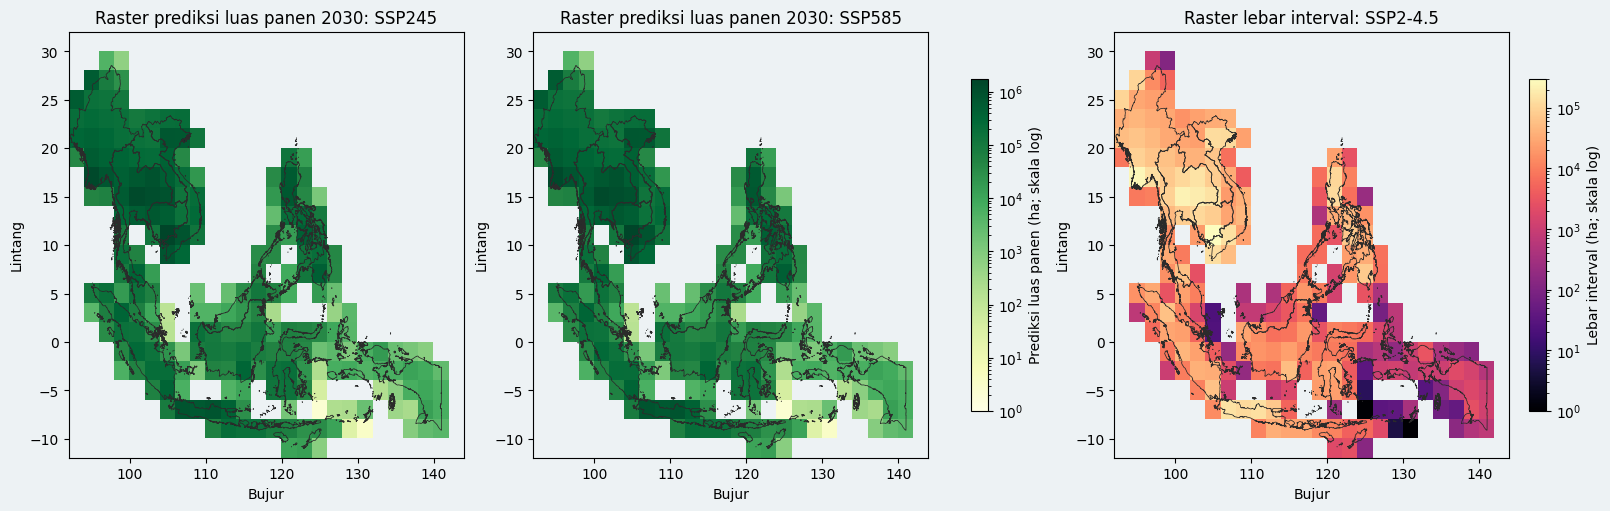

Catatan: interpretasikan perbedaan SSP2-4.5 versus SSP5-8.5 secara hati-hati karena perbedaan kovariat CMIP6 pada horizon ini lebih kecil daripada ketidakpastian posterior model.


In [3]:
import numpy as np
from matplotlib.colors import LogNorm

summary_2030 = pd.read_csv(MODEL_DIR / 'glorice_dynamic_bym2_ar1_cmip6_2030_2deg_summary.csv')
display(summary_2030)
scenarios = ['ssp245', 'ssp585']
maps_2030 = {s: pd.read_csv(MODEL_DIR / f'glorice_dynamic_bym2_ar1_{s}_2030_2deg.csv') for s in scenarios}
# Tepi piksel disusun dari raster GloRice 5-arcminute; ini menjaga lokasi grid model 2° tetap geografis, termasuk sel tepi yang parsial.
fine = np.load(PROCESSED / 'glorice/glorice_sea_intensive_harvested_area_1961_2021.npz')
lon_fine, lat_fine = fine['lon'], fine['lat']
step = abs(lon_fine[1] - lon_fine[0])
lon_edges = np.r_[ [lon_fine[i] - step/2 for i in range(0, len(lon_fine), 24)], lon_fine[-1] + step/2 ]
lat_edges = np.r_[ [lat_fine[i] + step/2 for i in range(0, len(lat_fine), 24)], lat_fine[-1] - step/2 ]
vmax = max(x['predicted_area_ha'].max() for x in maps_2030.values())
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True, facecolor='#edf2f4')
for ax, scenario in zip(axes[:2], scenarios):
    d = maps_2030[scenario]
    grid = d.pivot(index='row', columns='col', values='predicted_area_ha').sort_index().values
    img = ax.pcolormesh(lon_edges, lat_edges, grid, cmap='YlGn', norm=LogNorm(vmin=1, vmax=vmax), shading='flat')
    draw_asean_boundaries(ax)
    ax.set(title=f'Raster prediksi luas panen 2030: {scenario.upper()}', xlabel='Bujur', ylabel='Lintang', facecolor='#edf2f4')
fig.colorbar(img, ax=axes[:2], shrink=.78, label='Prediksi luas panen (ha; skala log)')
u = maps_2030['ssp245']
uncertainty = u.assign(width=u.predicted_upper_ha-u.predicted_lower_ha).pivot(index='row', columns='col', values='width').sort_index().values
img_u = axes[2].pcolormesh(lon_edges, lat_edges, uncertainty, cmap='magma', norm=LogNorm(vmin=1, vmax=uncertainty.max()), shading='flat')
draw_asean_boundaries(axes[2])
axes[2].set(title='Raster lebar interval: SSP2-4.5', xlabel='Bujur', ylabel='Lintang', facecolor='#edf2f4')
fig.colorbar(img_u, ax=axes[2], shrink=.78, label='Lebar interval (ha; skala log)')
plt.show()
print('Catatan: interpretasikan perbedaan SSP2-4.5 versus SSP5-8.5 secara hati-hati karena perbedaan kovariat CMIP6 pada horizon ini lebih kecil daripada ketidakpastian posterior model.')

,scenario,GID_0,COUNTRY,predicted_area_ha,predicted_lower_ha,predicted_upper_ha
8,ssp245,THA,Thailand,6.752283e+06,6.207878e+06,7.339650e+06
2,ssp245,IDN,Indonesia,4.985371e+06,4.577299e+06,5.426322e+06
5,ssp245,MMR,Myanmar,4.918981e+06,4.512011e+06,5.359185e+06
9,ssp245,VNM,Vietnam,3.260816e+06,2.989283e+06,3.554707e+06
1,ssp245,KHM,Cambodia,2.517362e+06,2.312205e+06,2.738940e+06
6,ssp245,PHL,Philippines,1.929119e+06,1.768124e+06,2.103411e+06
3,ssp245,LAO,Laos,1.434189e+06,1.317807e+06,1.559834e+06
4,ssp245,MYS,Malaysia,4.201204e+05,3.862199e+05,4.566992e+05
0,ssp245,BRN,Brunei,3.518331e+03,3.232230e+03,3.827264e+03
7,ssp245,SGP,Singapore,3.907507e+02,3.594220e+02,4.245334e+02


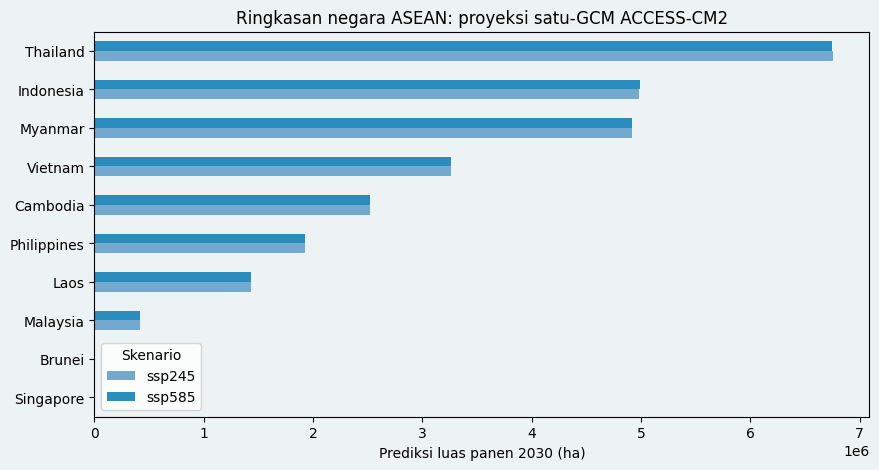

Peringatan resolusi: hasil negara kecil/kepulauan (khususnya Singapura dan Brunei) sangat sensitif terhadap grid model 2° dan tidak boleh dipakai untuk keputusan tingkat nasional.


In [4]:
country_2030 = pd.read_csv(MODEL_DIR / 'glorice_dynamic_bym2_ar1_cmip6_2030_country_summary.csv')
display(country_2030.sort_values(['scenario', 'predicted_area_ha'], ascending=[True, False]))
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#edf2f4')
ax.set_facecolor('#edf2f4')
wide = country_2030.pivot(index='COUNTRY', columns='scenario', values='predicted_area_ha').sort_values('ssp245')
wide.plot.barh(ax=ax, color=['#74a9cf', '#2b8cbe'])
ax.set(xlabel='Prediksi luas panen 2030 (ha)', ylabel='', title='Ringkasan negara ASEAN: proyeksi satu-GCM ACCESS-CM2')
ax.legend(title='Skenario')
plt.show()
print('Peringatan resolusi: hasil negara kecil/kepulauan (khususnya Singapura dan Brunei) sangat sensitif terhadap grid model 2° dan tidak boleh dipakai untuk keputusan tingkat nasional.')

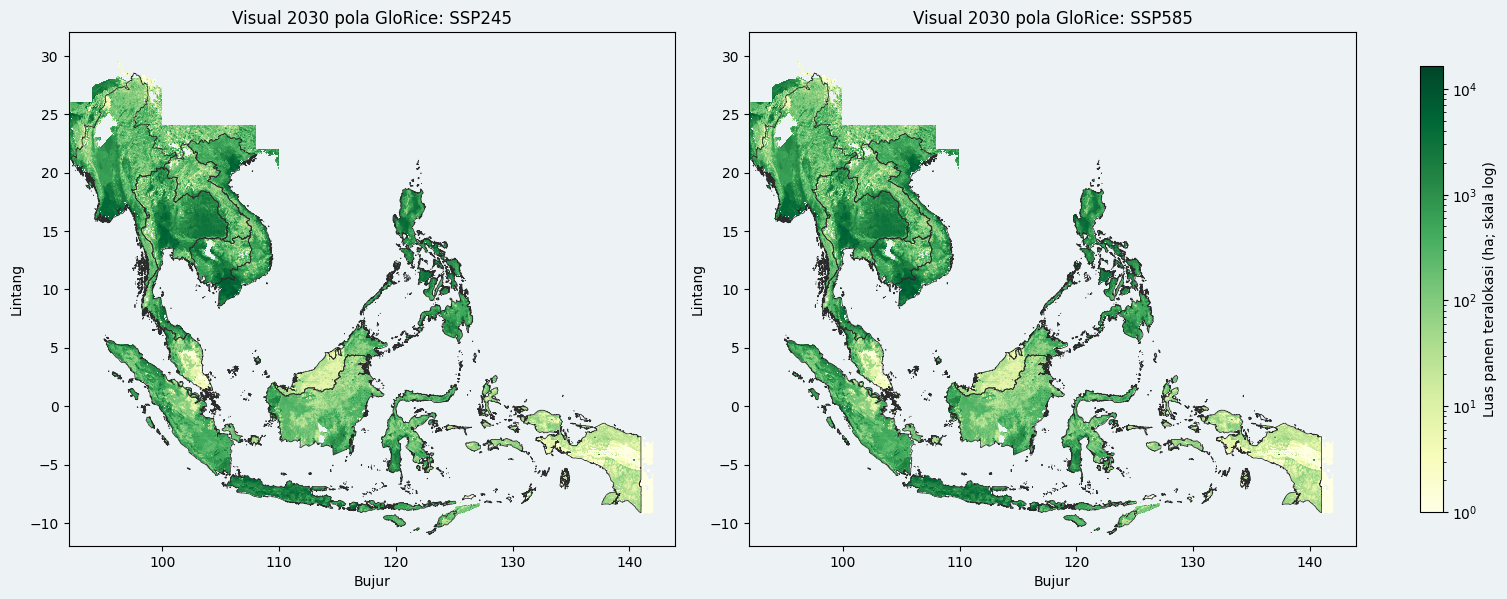

Interpretasi: detail lokasi mengikuti GloRice 2021; perubahan total luas panen berasal dari model 2°. Peta ini tidak membuktikan pergeseran lokasi sawah baru pada 2030.


In [5]:
import rasterio

tif_2030 = {s: MODEL_DIR / f'glorice_pattern_disaggregated_{s}_2030_5arcmin.tif' for s in scenarios}
with rasterio.open(tif_2030['ssp245']) as src:
    x2030 = src.read(1, masked=True)
    extent_2030 = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
with rasterio.open(tif_2030['ssp585']) as src:
    y2030 = src.read(1, masked=True)
vmax_2030 = max(x2030.max(), y2030.max())
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True, facecolor='#edf2f4')
for ax, values, scenario in zip(axes, [x2030, y2030], scenarios):
    img = ax.imshow(values, extent=extent_2030, origin='upper', cmap='YlGn', norm=LogNorm(vmin=1, vmax=vmax_2030), interpolation='nearest')
    draw_asean_boundaries(ax)
    ax.set(title=f'Visual 2030 pola GloRice: {scenario.upper()}', xlabel='Bujur', ylabel='Lintang', facecolor='#edf2f4')
fig.colorbar(img, ax=axes, shrink=.78, label='Luas panen teralokasi (ha; skala log)')
plt.show()
print('Interpretasi: detail lokasi mengikuti GloRice 2021; perubahan total luas panen berasal dari model 2°. Peta ini tidak membuktikan pergeseran lokasi sawah baru pada 2030.')